# Notebook 02: Money-Inflation TWFE (Short-run)

This notebook attempted to study short-run/YoY monetary-inflation relationship. 
It estimates within-country annual money-inflation associations using country and year fixed effects.

## Estimand and idea

The main model is:

`inflation_it = beta * m2_growth_it + country FE + year FE + error_it`

- `beta` is a **descriptive** within-country annual association, rather than causal policy effect.
- Country fixed effects remove time-invariant country differences.
- Year fixed effects remove global year shocks common to all countries.
- Standard errors are clustered by country unless explicitly marked otherwise.
- The **clean sample** drops countries with any inflation year above 40 percent.

In [1]:
## Packages and helper functions
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from linearmodels.panel import PanelOLS
warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
CONTROLS_PATH = ROOT / "02_data/supporting/wb_controls_1991_2024.csv"
FIG_DIR = ROOT / "04_current_results/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RESTRICTED_CONTROLS = ["trade_open", "pop_growth", "investment_share"]

for p in [PANEL_PATH, CONTROLS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

### Load panel data


In [2]:
base = pd.read_csv(PANEL_PATH)
controls = pd.read_csv(CONTROLS_PATH)

panel = (
    base.merge(controls, on=["Country Name", "year"], how="left")
        .rename(columns={"Country Name": "country"})
        .sort_values(["country", "year"])
        .copy()
)

panel_summary = pd.DataFrame({
    "metric": ["rows", "countries", "year_min", "year_max", "clean_countries"],
    "value": [
        len(panel),
        panel["country"].nunique(),
        int(panel["year"].min()),
        int(panel["year"].max()),
        panel.loc[panel["sample_low_inflation"] == 1, "country"].nunique(),
    ],
})
print(display(panel_summary))
panel.head()

,metric,value
0,rows,4750
1,countries,160
2,year_min,1991
3,year_max,2024
4,clean_countries,123


None


,country,year,m2_growth,inflation,gdp_growth,sample_main,sample_low_inflation,trade_open,gdp_pc_growth,pop_growth,investment_share
0,Afghanistan,2007,0.353436,0.083243,0.129504,1,1,NaN,11.692303,1.892598,NaN
1,Afghanistan,2008,0.272953,0.234429,0.038499,1,1,NaN,1.677279,2.186546,NaN
2,Afghanistan,2009,0.285518,-0.070542,0.193843,1,1,NaN,17.043896,3.646381,NaN
3,Afghanistan,2010,0.238600,0.021551,0.134203,1,1,NaN,11.055031,2.934687,NaN
4,Afghanistan,2011,0.193172,0.111579,0.004254,1,1,NaN,-3.213295,3.691503,NaN


### TWFE helpers


In [3]:
def run_fe(df, outcome, controls=None, cov_type="clustered", **fit_kwargs):
    controls = controls or []
    cols = ["country", "year", outcome, "m2_growth", *controls]
    fit_data = df[cols].dropna().set_index(["country", "year"]).sort_index()
    if fit_data.empty:
        raise ValueError("No complete observations for requested FE model")

    rhs = "m2_growth" + (" + " + " + ".join(controls) if controls else "")
    formula = f"{outcome} ~ 1 + {rhs} + EntityEffects + TimeEffects"

    if cov_type == "clustered" and not fit_kwargs:
        fit_kwargs = {"cluster_entity": True}
    return PanelOLS.from_formula(formula, data=fit_data).fit(cov_type=cov_type, **fit_kwargs)


def result_row(label, sample, outcome, res, cov="clustered_by_country"):
    return {
        "label": label,
        "sample": sample,
        "outcome": outcome,
        "covariance": cov,
        "coef_m2_growth": float(res.params["m2_growth"]),
        "se": float(res.std_errors["m2_growth"]),
        "t_stat": float(res.tstats["m2_growth"]),
        "p_value": float(res.pvalues["m2_growth"]),
        "within_r2": float(res.rsquared_within),
        "nobs": int(res.nobs),
    }


def fit_inflation_twfe(df, cov_type="clustered", **fit_kwargs):
    if cov_type == "clustered" and not fit_kwargs:
        fit_kwargs = {"cluster_entity": True}
    fit_df = df.dropna(subset=["inflation", "m2_growth"]).set_index(["country", "year"]).sort_index()
    formula = "inflation ~ 1 + m2_growth + EntityEffects + TimeEffects"
    return PanelOLS.from_formula(formula, data=fit_df).fit(cov_type=cov_type, **fit_kwargs)


### Baseline TWFE models

Inflation is the main outcome. GDP growth is retained as a secondary real-side check.


In [4]:
## Major FE results with inflation and M2
fe_infl_base = run_fe(panel, "inflation", controls=[])
## FE results with inflation and GDP
fe_gdp_base = run_fe(panel, "gdp_growth", controls=[])

## Major FE results with inflation and M2 with controls applied.
fe_infl_ctrl = run_fe(panel, "inflation", controls=RESTRICTED_CONTROLS)
fe_gdp_ctrl = run_fe(panel, "gdp_growth", controls=RESTRICTED_CONTROLS)

fe_table = pd.DataFrame([
    result_row("baseline", "full", "inflation", fe_infl_base),
    result_row("baseline", "full", "gdp_growth", fe_gdp_base),
    result_row("with_controls", "full", "inflation", fe_infl_ctrl),
    result_row("with_controls", "full", "gdp_growth", fe_gdp_ctrl),
])
display(fe_table)


,label,sample,outcome,covariance,coef_m2_growth,se,t_stat,p_value,within_r2,nobs
0,baseline,full,inflation,clustered_by_country,0.854882,0.075707,11.291965,0.000000,0.635484,4749
1,baseline,full,gdp_growth,clustered_by_country,-0.011196,0.011564,-0.968180,0.333006,0.000530,4749
2,with_controls,full,inflation,clustered_by_country,0.835843,0.093406,8.948500,0.000000,0.600047,3928
3,with_controls,full,gdp_growth,clustered_by_country,-0.011766,0.011426,-1.029797,0.303172,0.041325,3928


### Full vs clean sample

Similar to Notebook `01`, I am concerned that the Money-Inflation relationship is heterogenous for different inflation rate. Here, by filtering out the hyperinflation countries, the result change significantly. 

While this result is not causal, I believe this still implies a weakening correlation between money growth and inflation, especially when inflation is low. 


In [5]:
clean_panel = panel[panel["sample_low_inflation"] == 1].copy()

core_rows = [
    result_row("baseline", "full", "inflation", fe_infl_base),
    result_row("with_controls", "full", "inflation", fe_infl_ctrl),
    result_row("baseline", "clean_low_inflation", "inflation", fit_inflation_twfe(clean_panel)),
    result_row("with_controls", "clean_low_inflation", "inflation", run_fe(clean_panel, "inflation", controls=RESTRICTED_CONTROLS)),
]
core_table = pd.DataFrame(core_rows)
display(core_table)


,label,sample,outcome,covariance,coef_m2_growth,se,t_stat,p_value,within_r2,nobs
0,baseline,full,inflation,clustered_by_country,0.854882,0.075707,11.291965,0.000000e+00,0.635484,4749
1,with_controls,full,inflation,clustered_by_country,0.835843,0.093406,8.948500,0.000000e+00,0.600047,3928
2,baseline,clean_low_inflation,inflation,clustered_by_country,0.096136,0.013169,7.300471,3.537171e-13,0.060459,3638
3,with_controls,clean_low_inflation,inflation,clustered_by_country,0.104708,0.014909,7.023139,2.689626e-12,0.072806,3056


### Pre/post-2008 TWFE split

This is part of the main story: short-run Money-Inflation relation has a "regime change" in recent data.
The same clean-sample TWFE specification is estimated separately across monetary-regime periods.


In [6]:
periods = {
    "1991-2007_pre_2008": (1991, 2007),
    "2008-2019_qe_era": (2008, 2019),
    "2020-2024_covid_post": (2020, 2024),
}

period_rows = []
for label, (y0, y1) in periods.items():
    sub = clean_panel[(clean_panel["year"] >= y0) & (clean_panel["year"] <= y1)].copy()
    sub_fit = sub.dropna(subset=["inflation", "m2_growth"])
    if len(sub_fit) < 50:
        continue
    res = fit_inflation_twfe(sub)
    row = result_row("period_split", label, "inflation", res)
    row["year_min"] = y0
    row["year_max"] = y1
    row["countries"] = int(sub_fit["country"].nunique())
    period_rows.append(row)

period_table = pd.DataFrame(period_rows)
display(period_table[["sample", "coef_m2_growth", "se", "p_value", "within_r2", "nobs", "countries"]])


,sample,coef_m2_growth,se,p_value,within_r2,nobs,countries
0,1991-2007_pre_2008,0.112794,0.018601,1.648698e-09,0.067288,1764,119
1,2008-2019_qe_era,-0.006279,0.016958,7.112549e-01,-0.003011,1397,123
2,2020-2024_covid_post,-0.013850,0.030944,6.547154e-01,0.005279,477,107


#### Pre/post-2008 coefficient plot

The graph uses separate TWFE regressions by period. This estimates a descriptive within-country slope inside each era; it is not a causal QE design. The 2020-2024 bin is short, so it is a noisy COVID-era robustness check.


,period,coef,se,ci_low,ci_high,pval,nobs,n_countries,n_years
0,1991-2007,0.113,0.019,0.076,0.149,0.0000,1764,119,17
1,2008-2019,-0.006,0.017,-0.040,0.027,0.7113,1397,123,12
2,2020-2024,-0.014,0.031,-0.075,0.047,0.6547,477,107,5


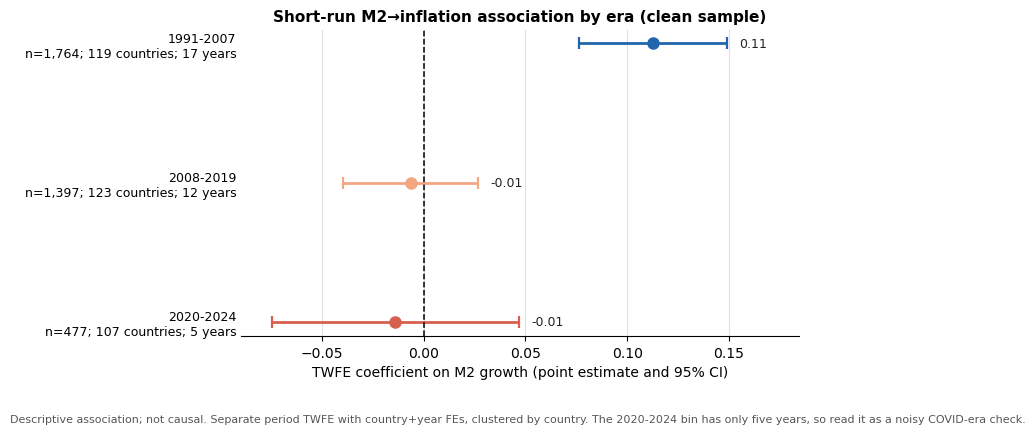

Saved: pre_post_2008_coef_plot.png


In [7]:
# Extension 4: coefficient plot for pre/post-2008 periods (clean sample)
# Estimand in each era: inflation_it = alpha_i + gamma_t + beta * m2_growth_it + error_it.
# Each period is estimated separately, so country and year FEs are estimated within period.

_period_specs = [
    ("1991-2007", 1991, 2007, "#2166ac"),
    ("2008-2019", 2008, 2019, "#f4a582"),
    ("2020-2024", 2020, 2024, "#d6604d"),
]

_coef_rows = []
for _label, _y0, _y1, _color in _period_specs:
    _sub = clean_panel[(clean_panel["year"] >= _y0) & (clean_panel["year"] <= _y1)].copy()
    _sub_fit = _sub.dropna(subset=["inflation", "m2_growth"])
    _res = fit_inflation_twfe(_sub)
    _coef_rows.append({
        "period": _label,
        "year_min": _y0,
        "year_max": _y1,
        "coef": float(_res.params["m2_growth"]),
        "se": float(_res.std_errors["m2_growth"]),
        "pval": float(_res.pvalues["m2_growth"]),
        "nobs": int(_res.nobs),
        "n_countries": int(_sub_fit["country"].nunique()),
        "n_years": int(_sub_fit["year"].nunique()),
        "color": _color,
    })

_coef_plot = pd.DataFrame(_coef_rows)
_coef_plot["ci95"] = 1.96 * _coef_plot["se"]
_coef_plot["ci_low"] = _coef_plot["coef"] - _coef_plot["ci95"]
_coef_plot["ci_high"] = _coef_plot["coef"] + _coef_plot["ci95"]

display(
    _coef_plot[["period", "coef", "se", "ci_low", "ci_high", "pval", "nobs", "n_countries", "n_years"]]
        .round({"coef": 3, "se": 3, "ci_low": 3, "ci_high": 3, "pval": 4})
)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
_y = np.arange(len(_coef_plot))

for _ypos, (_, _row) in zip(_y, _coef_plot.iterrows()):
    ax.errorbar(
        _row["coef"], _ypos,
        xerr=_row["ci95"],
        fmt="o", markersize=8,
        color=_row["color"], ecolor=_row["color"],
        capsize=4, capthick=1.6, linewidth=2,
    )
    ax.text(
        _row["ci_high"] + 0.006, _ypos,
        f'{_row["coef"]:.2f}',
        va="center", ha="left", fontsize=9, color="#222222",
    )

_axis_labels = [
    f'{_row["period"]}\nn={_row["nobs"]:,}; {_row["n_countries"]} countries; {_row["n_years"]} years'
    for _, _row in _coef_plot.iterrows()
]

ax.axvline(0, color="black", lw=1.1, linestyle="--")
ax.set_yticks(_y)
ax.set_yticklabels(_axis_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("TWFE coefficient on M2 growth (point estimate and 95% CI)", fontsize=10)
ax.set_title(
    "Short-run M2→inflation association by era (clean sample)",
    fontsize=11, fontweight="bold",
)
ax.grid(axis="x", color="#d9d9d9", linewidth=0.8, alpha=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(min(0, _coef_plot["ci_low"].min()) - 0.015, _coef_plot["ci_high"].max() + 0.035)

fig.text(
    0.02, 0.02,
    "Descriptive association; not causal. Separate period TWFE with country+year FEs, clustered by country. "
    "The 2020-2024 bin has only five years, so read it as a noisy COVID-era check.",
    fontsize=8, color="#555555",
)
fig.tight_layout(rect=(0.02, 0.08, 1, 0.95))
fig.savefig(FIG_DIR / "pre_post_2008_coef_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pre_post_2008_coef_plot.png")


The clean-sample annual within-country slope is positive before 2008 and close to zero in 2008-2019. The 2020-2024 estimate is also statistically indistinguishable from zero, but the window is too short to interpret as a stable era-specific slope.


### Inflation-regime split

Does the M2→inflation slope vary by the prior-year inflation level? Regime defined on lagged inflation to avoid conditioning on the outcome.

,regime,coef,se,ci_low,ci_high,pval,nobs,n_countries
0,Low (<=5%),0.053,0.012,0.030,0.077,0.0000,2540,149
1,Moderate (5-20%],0.108,0.028,0.054,0.162,0.0001,1720,156
2,High (20-40%],0.287,0.158,-0.024,0.597,0.0734,205,73
3,Extreme (>40%),0.893,0.103,0.690,1.096,0.0000,124,36


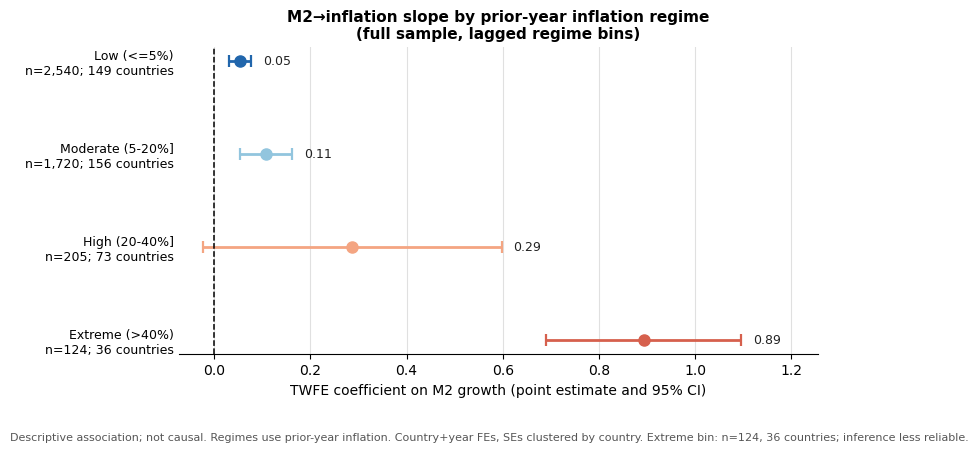

Saved: regime_split_coef_plot.png


In [8]:
# Extension 1: inflation-regime split using lagged inflation bins
# Regime defined on prior-year inflation to avoid conditioning on the outcome.
# pd.cut(right=True): bins are (lo, hi] - boundary values fall into the lower-inflation bin.

_reg = panel[panel["sample_main"] == 1].copy().sort_values(["country", "year"])
_reg["infl_l1"] = _reg.groupby("country")["inflation"].shift(1)

_bins = [-np.inf, 0.05, 0.20, 0.40, np.inf]
_labels = ["Low (<=5%)", "Moderate (5-20%]", "High (20-40%]", "Extreme (>40%)"]
_reg["regime"] = pd.cut(_reg["infl_l1"], bins=_bins, labels=_labels)

_colors = {
    "Low (<=5%)": "#2166ac",
    "Moderate (5-20%]": "#92c5de",
    "High (20-40%]": "#f4a582",
    "Extreme (>40%)": "#d6604d",
}

_regime_results = []
for _lbl in _labels:
    _sub = _reg[_reg["regime"] == _lbl].dropna(subset=["inflation", "m2_growth"])
    if len(_sub) < 50 or _sub["country"].nunique() < 5:
        continue
    _res = fit_inflation_twfe(_sub)
    _regime_results.append({
        "regime": _lbl,
        "coef": float(_res.params["m2_growth"]),
        "se": float(_res.std_errors["m2_growth"]),
        "pval": float(_res.pvalues["m2_growth"]),
        "nobs": int(_res.nobs),
        "n_countries": int(_sub["country"].nunique()),
        "color": _colors[_lbl],
    })

_regime_plot = pd.DataFrame(_regime_results)
_regime_plot["ci95"] = 1.96 * _regime_plot["se"]
_regime_plot["ci_low"] = _regime_plot["coef"] - _regime_plot["ci95"]
_regime_plot["ci_high"] = _regime_plot["coef"] + _regime_plot["ci95"]

# Keep the estimates visible as a table; the figure below is just the visual summary.
display(
    _regime_plot[["regime", "coef", "se", "ci_low", "ci_high", "pval", "nobs", "n_countries"]]
        .round({"coef": 3, "se": 3, "ci_low": 3, "ci_high": 3, "pval": 4})
)

fig, ax = plt.subplots(figsize=(8.4, 4.8))
_y = np.arange(len(_regime_plot))

for _ypos, (_, _r) in zip(_y, _regime_plot.iterrows()):
    ax.errorbar(
        _r["coef"], _ypos,
        xerr=_r["ci95"],
        fmt="o", markersize=8,
        color=_r["color"], ecolor=_r["color"],
        capsize=4, capthick=1.6, linewidth=2,
    )
    ax.text(
        _r["ci_high"] + 0.025, _ypos,
        f'{_r["coef"]:.2f}',
        va="center", ha="left", fontsize=9, color="#222222",
    )

_axis_labels = [
    f'{_r["regime"]}\nn={_r["nobs"]:,}; {_r["n_countries"]} countries'
    for _, _r in _regime_plot.iterrows()
]

ax.axvline(0, color="black", lw=1.1, linestyle="--")
ax.set_yticks(_y)
ax.set_yticklabels(_axis_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("TWFE coefficient on M2 growth (point estimate and 95% CI)", fontsize=10)
ax.set_title(
    "M2→inflation slope by prior-year inflation regime\n(full sample, lagged regime bins)",
    fontsize=11, fontweight="bold",
)
ax.grid(axis="x", color="#d9d9d9", linewidth=0.8, alpha=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

_xlim_left = min(0, _regime_plot["ci_low"].min()) - 0.05
_xlim_right = _regime_plot["ci_high"].max() + 0.16
ax.set_xlim(_xlim_left, _xlim_right)

_extreme = _regime_plot.loc[_regime_plot["regime"].str.startswith("Extreme")].iloc[0]
fig.text(
    0.02, 0.02,
    "Descriptive association; not causal. Regimes use prior-year inflation. "
    "Country+year FEs, SEs clustered by country. "
    f'Extreme bin: n={_extreme["nobs"]:,}, {int(_extreme["n_countries"])} countries; inference less reliable.',
    fontsize=8, color="#555555",
)
fig.tight_layout(rect=(0.02, 0.08, 1, 0.95))
fig.savefig(FIG_DIR / "regime_split_coef_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: regime_split_coef_plot.png")


The descriptive slope is larger in higher-inflation regimes — consistent with the quantity-theory prior. In low prior-year inflation environments, the annual within-country M2→inflation association is weak, similar to the main clean-sample result.

### Compact robustness layer

These rows check whether the main short-run pattern is just a COVID-year artifact or an inference artifact. They are diagnostics for the same descriptive TWFE estimand, not new claims.


In [9]:
panel_no_covid = panel[~panel["year"].isin([2020, 2021])].copy()
clean_no_covid = panel_no_covid[panel_no_covid["sample_low_inflation"] == 1].copy()

robustness_rows = [
    result_row("clustered", "full", "inflation", fe_infl_base),
    result_row("clustered", "full_ex_2020_2021", "inflation", fit_inflation_twfe(panel_no_covid)),
    result_row("clustered", "clean_low_inflation", "inflation", fit_inflation_twfe(clean_panel)),
    result_row("clustered", "clean_ex_2020_2021", "inflation", fit_inflation_twfe(clean_no_covid)),
    result_row(
        "driscoll_kraay_bw4",
        "full",
        "inflation",
        fit_inflation_twfe(panel, cov_type="kernel", kernel="bartlett", bandwidth=4),
        cov="driscoll_kraay_bw4",
    ),
    result_row(
        "driscoll_kraay_bw4",
        "clean_low_inflation",
        "inflation",
        fit_inflation_twfe(clean_panel, cov_type="kernel", kernel="bartlett", bandwidth=4),
        cov="driscoll_kraay_bw4",
    ),
]
robustness_table = pd.DataFrame(robustness_rows)
display(robustness_table[["label", "sample", "coef_m2_growth", "se", "t_stat", "p_value", "nobs"]])


,label,sample,coef_m2_growth,se,t_stat,p_value,nobs
0,clustered,full,0.854882,0.075707,11.291965,0.000000e+00,4749
1,clustered,full_ex_2020_2021,0.857690,0.077187,11.111899,0.000000e+00,4478
2,clustered,clean_low_inflation,0.096136,0.013169,7.300471,3.537171e-13,3638
3,clustered,clean_ex_2020_2021,0.098964,0.013869,7.135442,1.182388e-12,3430
4,driscoll_kraay_bw4,full,0.854882,0.136628,6.257017,4.284570e-10,4749
5,driscoll_kraay_bw4,clean_low_inflation,0.096136,0.042365,2.269247,2.331425e-02,3638


### Outlier robustness

Is the main result sensitive to extreme observations? Same TWFE run under five sample restrictions. Specs 3–4 trim the regressor; specs 5 and the clean sample restrict the outcome distribution.
DV truncation mechanically compresses slopes and reflects genuine heterogeneity, not just outlier influence.

In [10]:
# Extension 3: outlier robustness — same TWFE across five sample restrictions

# Spec 1: full sample (sample_main == 1)
_full = panel[panel["sample_main"] == 1].copy()

# Spec 2: clean sample (sample_low_inflation == 1)
_clean = panel[panel["sample_low_inflation"] == 1].copy()

# Spec 3: winsorized 1/99 on m2_growth and inflation (within full sample)
_wins = _full.copy()
_m2_lo, _m2_hi = _wins["m2_growth"].quantile([0.01, 0.99])
_inf_lo, _inf_hi = _wins["inflation"].quantile([0.01, 0.99])
_wins["m2_growth"] = _wins["m2_growth"].clip(_m2_lo, _m2_hi)
_wins["inflation"] = _wins["inflation"].clip(_inf_lo, _inf_hi)

# Spec 4: exclude |m2_growth| > 1.0 (>100% growth)
_ex_m2 = _full[_full["m2_growth"].abs() <= 1.0].copy()

# Spec 5: exclude inflation > 0.40 (>40%)
_ex_inf = _full[_full["inflation"] <= 0.40].copy()

_outlier_specs = [
    ("Full sample",             _full),
    ("Clean sample",            _clean),
    ("Winsorized 1/99",         _wins),
    ("Exclude |m2_growth|>1.0", _ex_m2),
    ("Exclude inflation>0.40",  _ex_inf),
]

_out_rows = []
for _spec_label, _df in _outlier_specs:
    _res = fit_inflation_twfe(_df)
    _out_rows.append({
        "Spec":    _spec_label,
        "Coef":   round(float(_res.params["m2_growth"]), 4),
        "SE":     round(float(_res.std_errors["m2_growth"]), 4),
        "p-value": round(float(_res.pvalues["m2_growth"]), 4),
        "N":      int(_res.nobs),
    })

_outlier_table = pd.DataFrame(_out_rows)
print("Outlier robustness: same model, different sample restrictions.")
display(_outlier_table)


Outlier robustness: same model, different sample restrictions.


,Spec,Coef,SE,p-value,N
0,Full sample,0.8549,0.0757,0.0,4749
1,Clean sample,0.0961,0.0132,0.0,3638
2,Winsorized 1/99,0.4222,0.0481,0.0,4749
3,Exclude |m2_growth|>1.0,0.3278,0.0585,0.0,4717
4,Exclude inflation>0.40,0.1140,0.0146,0.0,4621


### Between-vs-within wedge

This figure compares two named clean-sample specifications:

- Between countries: clean long-run country averages with the same `n_obs >= 30` screen used in Notebook 01.
- Within countries: clean TWFE residual variation after absorbing country and year fixed effects.


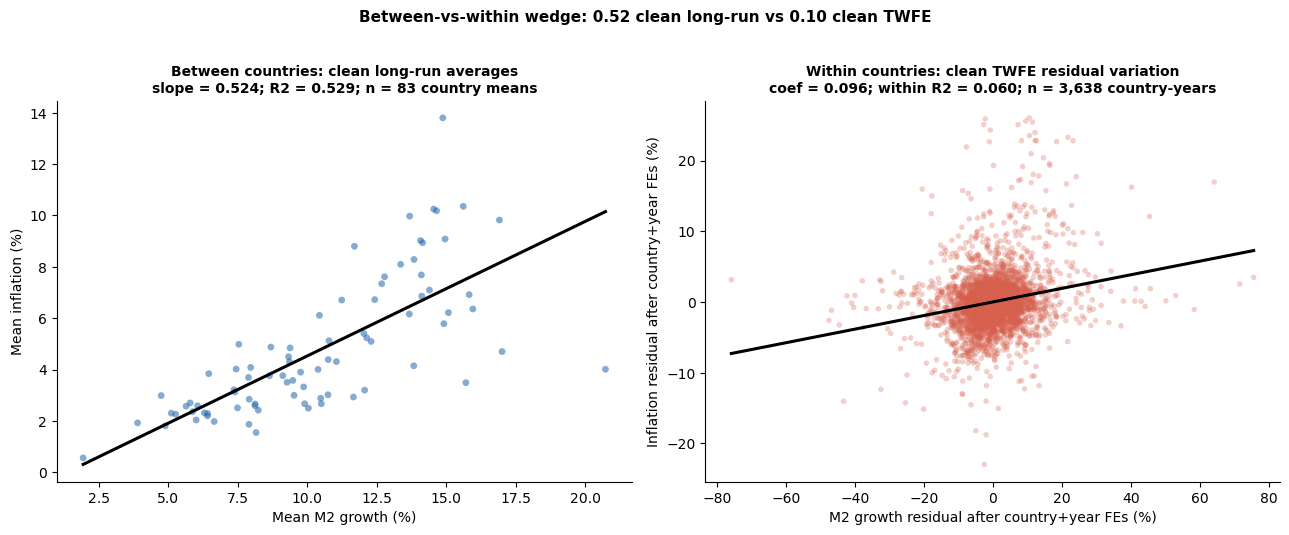

Saved: between_within_decomposition.png | between=0.524, within=0.096


In [11]:
# Compare named clean-sample specs, not an unlabeled intermediate sample.
_min_longrun_obs = 30
clean = clean_panel.dropna(subset=["m2_growth", "inflation"]).copy()

country_means = (
    clean.groupby("country", as_index=False)
    .agg(
        m2_growth=("m2_growth", "mean"),
        inflation=("inflation", "mean"),
        n_obs=("year", "count"),
    )
)
country_means = country_means[country_means["n_obs"] >= _min_longrun_obs].dropna(
    subset=["m2_growth", "inflation"]
)

between_slope, between_intercept, between_r, _, _ = stats.linregress(
    (country_means["m2_growth"] * 100).to_numpy(),
    (country_means["inflation"] * 100).to_numpy(),
)

fit_data = clean.set_index(["country", "year"]).sort_index()
twfe_res = fit_inflation_twfe(clean)

m2_resid = PanelOLS.from_formula(
    "m2_growth ~ 1 + EntityEffects + TimeEffects",
    data=fit_data,
).fit().resids
inf_resid = PanelOLS.from_formula(
    "inflation ~ 1 + EntityEffects + TimeEffects",
    data=fit_data,
).fit().resids

within_plot = pd.DataFrame({
    "m2_resid": m2_resid,
    "inf_resid": inf_resid,
}).dropna()
within_slope = float(twfe_res.params["m2_growth"])
within_intercept = 0.0
within_r2 = float(twfe_res.rsquared_within)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Between panel: named clean long-run country-average specification.
x_between = country_means["m2_growth"] * 100
y_between = country_means["inflation"] * 100
axes[0].scatter(x_between, y_between, alpha=0.55, s=24, color="#2166ac", edgecolors="none")
xfit = np.linspace(float(x_between.min()), float(x_between.max()), 100)
axes[0].plot(xfit, between_intercept + between_slope * xfit, color="black", lw=2.2)
axes[0].set_title(
    f"Between countries: clean long-run averages\n"
    f"slope = {between_slope:.3f}; R2 = {between_r**2:.3f}; n = {len(country_means)} country means",
    fontsize=10,
    fontweight="bold",
)
axes[0].set_xlabel("Mean M2 growth (%)")
axes[0].set_ylabel("Mean inflation (%)")
axes[0].spines[["top", "right"]].set_visible(False)

# Within panel: clean TWFE residualized on country and year fixed effects.
x_within = within_plot["m2_resid"] * 100
y_within = within_plot["inf_resid"] * 100
axes[1].scatter(x_within, y_within, alpha=0.30, s=16, color="#d6604d", edgecolors="none")
xfit = np.linspace(float(x_within.min()), float(x_within.max()), 100)
axes[1].plot(xfit, within_intercept + within_slope * xfit, color="black", lw=2.2)
axes[1].set_title(
    f"Within countries: clean TWFE residual variation\n"
    f"coef = {within_slope:.3f}; within R2 = {within_r2:.3f}; n = {int(twfe_res.nobs):,} country-years",
    fontsize=10,
    fontweight="bold",
)
axes[1].set_xlabel("M2 growth residual after country+year FEs (%)")
axes[1].set_ylabel("Inflation residual after country+year FEs (%)")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Between-vs-within wedge: {between_slope:.2f} clean long-run vs {within_slope:.2f} clean TWFE",
    fontsize=11,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIG_DIR / "between_within_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    "Saved: between_within_decomposition.png | "
    f"between={between_slope:.3f}, within={within_slope:.3f}"
)
